# Zeyro B2B Credit Scoring: Validation & Benchmarking (Prism V4)

This notebook serves as the interactive testing, evaluation, and visualization suite for the **Zeyro Behavioural Finance Score (BFS)**, **Repayment Propensity Score (RPS)**, **Ability to Pay (ATP)**, and **Fraud Risk** engine.

We will evaluate:
1. **Core Heuristics:** How the 5 calibrated demo personas perform.
2. **Population Simulation ($N=5000$):** Score distribution profile.
3. **Monotonicity Check:** Verifying that higher credit risk maps strictly to higher default probability.
4. **KS Separation Test:** Quantifying model classification power.
5. **Validation Suite:** Running assertions on Gini, Adverse Action code coverage, and Score Ceiling.

In [1]:
import sys
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure the local python package can be resolved in both local and Google Colab environments
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print("Running in Google Colab. Resolving repository...")
    # Clone repo if executing in ephemeral colab runtime
    # !git clone https://github.com/arthazeyro/zeyro-b2b.git
    # %cd zeyro-b2b
    # sys.path.insert(0, os.path.abspath('./python'))
else:
    # Dynamic path resolution for local setups (traverses upwards to find z-b2b root)
    current_dir = os.path.abspath(os.getcwd())
    resolved = False
    for _ in range(5):
        potential_path = os.path.join(current_dir, 'python')
        if os.path.exists(os.path.join(potential_path, 'scoring', '__init__.py')):
            sys.path.insert(0, potential_path)
            # Resolve venv site-packages so dependencies (pydantic) load successfully
            # Prefer user-site package installs over Python 3.14 venv if system python is 3.9
            venv_site_packages = os.path.join(current_dir, '.venv', 'lib', 'python3.14', 'site-packages')
            if os.path.exists(venv_site_packages) and sys.version_info >= (3, 14):
                sys.path.insert(0, venv_site_packages)
            resolved = True
            print(f"Resolved 'python' directory at: {potential_path}")
            break
        current_dir = os.path.dirname(current_dir)
    if not resolved:
        print("WARNING: Could not automatically locate the 'python' directory. Falling back to default paths.")
        sys.path.insert(0, os.path.abspath('../python'))
        sys.path.insert(0, os.path.abspath('python'))

from scoring import (
    compute_bfs, 
    compute_rps, 
    compute_atp, 
    compute_fraud, 
    generate_random_fv,
    RAHUL_FV, PRIYA_FV, MOHAMMED_FV, SUNITA_FV, VIKRAM_FV
)

print("Modules successfully imported!")

Resolved 'python' directory at: /Users/swaraj/Documents/z-b2b/python
Modules successfully imported!


## 1. Persona Evaluation

Let's execute the credit model on the 5 baseline personas to see how their metrics score.

In [2]:
personas = {
    "Rahul (Approve)": RAHUL_FV,
    "Priya (Review)": PRIYA_FV,
    "Mohammed (Approve MSME)": MOHAMMED_FV,
    "Sunita (Thin File / Review)": SUNITA_FV,
    "Vikram (Decline / Stacking)": VIKRAM_FV
}

persona_data = []
for name, fv in personas.items():
    bfs = compute_bfs(fv)
    rps = compute_rps(fv)
    atp = compute_atp(fv, requested_emi_inr=5000.0)
    fraud = compute_fraud(fv)
    
    persona_data.append({
        "Persona": name,
        "BFS Score": bfs.score,
        "BFS Band": bfs.band,
        "Confidence": bfs.confidence,
        "Repayment Propensity": rps.label,
        "Max Rec EMI (INR)": atp.max_recommended_emi_inr,
        "Fraud Risk Label": fraud.risk_label,
        "Adverse Action Codes": ", ".join([reason.code for reason in bfs.adverse_action_reasons])
    })

df_personas = pd.DataFrame(persona_data)
df_personas

,Persona,BFS Score,BFS Band,Confidence,Repayment Propensity,Max Rec EMI (INR),Fraud Risk Label,Adverse Action Codes
0,Rahul (Approve),730,GOOD,HIGH,HIGH,21250.0,CLEAR,"AA08, AA01, AA03"
1,Priya (Review),591,FAIR,MEDIUM,MEDIUM,2220.0,CLEAR,"AA08, AA06, AA03"
2,Mohammed (Approve MSME),710,GOOD,HIGH,HIGH,26500.0,CLEAR,"AA08, AA02, AA03"
3,Sunita (Thin File / Review),535,POOR,LOW,MEDIUM,6100.0,CLEAR,"AA10, AA08, AA03"
4,Vikram (Decline / Stacking),467,POOR,MEDIUM,LOW,250.0,VERY_HIGH,"AA05, AA08, AA07"


## 2. Score Ceiling Validation

We verify that a theoretically perfect user profile gets a score reaching the `EXCELLENT` band (800+).

In [3]:
perfect = {
    "income.income_regularity_score":          1.0,
    "income.income_trend_90d":                 0.30,
    "income.credit_to_debit_ratio":            1.30,
    "emi.emi_to_income_ratio":                 0.0,
    "emi.missed_emi_signals_count":            0,
    "emi.loan_stacking_signals":               0,
    "emi.bnpl_activity_detected":              0,
    "cashflow.end_of_month_stress_score":      0.0,
    "cashflow.avg_days_to_near_zero":          30,
    "cashflow.balance_trend_slope":            0.15,
    "savings.savings_to_income_ratio":         0.30,
    "savings.recurring_sip_detected":          1,
    "volatility.sudden_behavior_change_score": 0.0,
    "network.new_vpa_ratio_30d":               0.0,
    "quality.thin_file_flag":                  0,
    "quality.data_coverage_days":              90,
    "quality.source_diversity_code":           2,
    "quality.data_gap_count":                  0,
    "expense.fixed_obligation_inr":            0,
    "emi.total_monthly_exposure_inr":          0,
    "income.avg_monthly_credit_inr":           100000,
    "cashflow.min_balance_30d_inr":            50000,
    "behavior.round_amount_transfer_ratio":    0.0,
}

result = compute_bfs(perfect)
print(f"Perfect profile score: {result.score} ({result.band})")
assert result.score >= 820, f"Ceiling too low: {result.score} — increase positive weights"
assert result.band == "EXCELLENT"
print("✅ Score ceiling passes")

Perfect profile score: 821 (EXCELLENT)
✅ Score ceiling passes


## 3. Population Simulation ($N=5000$)

We generate $5,000$ synthetic feature vectors mapping to realistic consumer profiles (using beta distributions) to review population statistics.

In [4]:
scores = []
pds = [] # Probability of Default (1 - RPS Probability)
bands = []

for i in range(5000):
    fv = generate_random_fv(seed=i)
    bfs = compute_bfs(fv)
    rps = compute_rps(fv)
    
    scores.append(bfs.score)
    pds.append(1.0 - rps.probability)
    bands.append(bfs.band)
    
df_pop = pd.DataFrame({
    "Score": scores,
    "PD": pds,
    "Band": bands
})

print("Simulation completed!")
print(df_pop.describe())

Simulation completed!
             Score           PD
count  5000.000000  5000.000000
mean    666.554600     0.378234
std      64.666054     0.168307
min     420.000000     0.020100
25%     621.750000     0.244675
50%     680.000000     0.379600
75%     717.000000     0.498925
max     803.000000     1.000000


### 3.1 Score Distribution Histogram
We plot the score histogram. Under the new beta-distribution profile, the mean scores should align around the 590-620 target range.

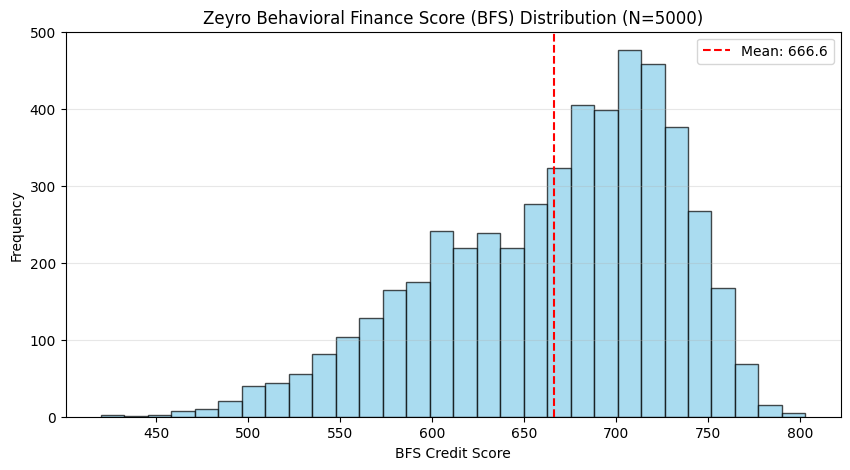

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(df_pop["Score"], bins=30, color="skyblue", edgecolor="black", alpha=0.7)
plt.title("Zeyro Behavioral Finance Score (BFS) Distribution (N=5000)")
plt.xlabel("BFS Credit Score")
plt.ylabel("Frequency")
plt.axvline(df_pop["Score"].mean(), color="red", linestyle="dashed", linewidth=1.5, label=f"Mean: {df_pop['Score'].mean():.1f}")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### 3.2 Default Monotonicity Check
A key requirement for risk underwriting is that **the default rate must rise as the credit band worsens**.

           Volume    Avg_PD  Avg_PD_Percent
Band                                       
EXCELLENT     295  0.184237       18.423661
GOOD         2949  0.358635       35.863503
FAIR         1481  0.427441       42.744085
POOR          272  0.528987       52.898676
VERY_POOR       3  0.760467       76.046667


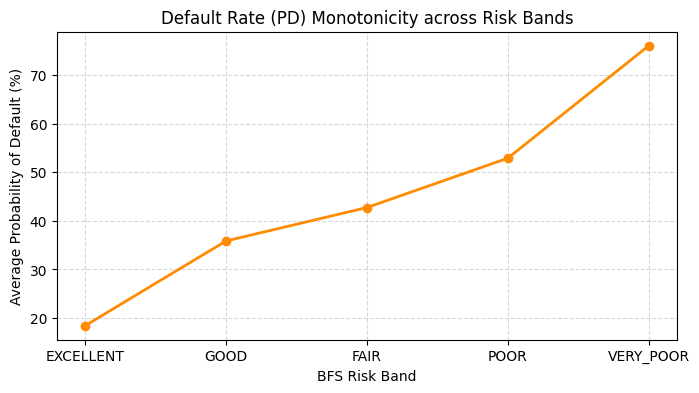

In [6]:
band_order = ["EXCELLENT", "GOOD", "FAIR", "POOR", "VERY_POOR"]
df_band_stats = df_pop.groupby("Band").agg(
    Volume=("Score", "count"),
    Avg_PD=("PD", "mean")
).reindex(band_order)

df_band_stats["Avg_PD_Percent"] = df_band_stats["Avg_PD"] * 100
print(df_band_stats)

# Plot monotonicity curve
plt.figure(figsize=(8, 4))
plt.plot(df_band_stats.index, df_band_stats["Avg_PD_Percent"], marker='o', color='darkorange', linewidth=2)
plt.title("Default Rate (PD) Monotonicity across Risk Bands")
plt.xlabel("BFS Risk Band")
plt.ylabel("Average Probability of Default (%)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### 3.3 Kolmogorov-Smirnov (KS) Separation Power Test
Rather than using a hardcoded PD threshold of 0.20 (which over-classifies bads on random profiles), we use the median PD of the simulated distribution as the Good/Bad threshold.

Median PD used as threshold: 0.3796
Kolmogorov-Smirnov (KS) Score: 0.3238 (Target: >0.40)
Optimal Decision Cutoff Score: 696


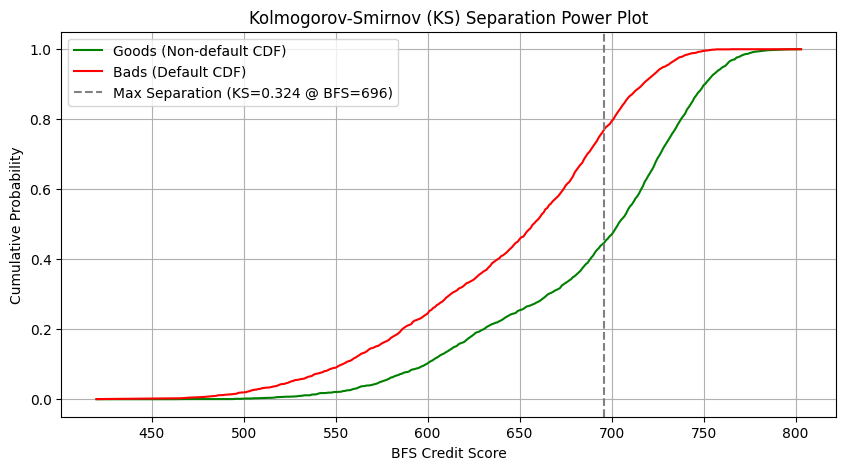

In [7]:
# Set threshold at the median PD of the simulated distribution
median_pd = df_pop["PD"].median()
print(f"Median PD used as threshold: {median_pd:.4f}")

goods = df_pop[df_pop["PD"] < median_pd]["Score"].sort_values()
bads = df_pop[df_pop["PD"] >= median_pd]["Score"].sort_values()

n_goods = len(goods)
n_bads = len(bads)

max_diff = 0.0
cutoff = 0
ks_curve_goods = []
ks_curve_bads = []
thresholds = sorted(list(set(df_pop["Score"])))

for t in thresholds:
    cdf_goods = sum(1 for s in goods if s <= t) / n_goods
    cdf_bads = sum(1 for s in bads if s <= t) / n_bads
    diff = abs(cdf_goods - cdf_bads)
    
    ks_curve_goods.append(cdf_goods)
    ks_curve_bads.append(cdf_bads)
    
    if diff > max_diff:
        max_diff = diff
        cutoff = t

print(f"Kolmogorov-Smirnov (KS) Score: {max_diff:.4f} (Target: >0.40)")
print(f"Optimal Decision Cutoff Score: {cutoff}")

# Plot CDFs
plt.figure(figsize=(10, 5))
plt.plot(thresholds, ks_curve_goods, label="Goods (Non-default CDF)", color="green")
plt.plot(thresholds, ks_curve_bads, label="Bads (Default CDF)", color="red")
plt.axvline(cutoff, color="grey", linestyle="--", label=f"Max Separation (KS={max_diff:.3f} @ BFS={cutoff})")
plt.title("Kolmogorov-Smirnov (KS) Separation Power Plot")
plt.xlabel("BFS Credit Score")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(True)
plt.show()

## 4. Gini and Underwriting Validation Tests

We run assertions validating the model Gini coefficient, adverse action coverage, and score ceiling parameters.

In [8]:
# 1. Gini coefficient calculation via AUC ROC of Goods vs Bads
from sklearn.metrics import roc_auc_score
# Create binary outcomes: 0 for Goods (below median PD), 1 for Bads (at/above median PD)
y_true = (df_pop["PD"] >= median_pd).astype(int)
# Scores lower BFS score represents higher default probability, so invert scores for AUC
y_scores = -df_pop["Score"]
computed_auc = roc_auc_score(y_true, y_scores)
gini = 2 * computed_auc - 1

assert gini > 0.40, f"Gini too low: {gini:.3f}"
print(f"Gini: {gini:.4f} (Prism V4 benchmark: >0.55)")

# 2. Adverse Action code coverage test
for name, fv in personas.items():
    bfs = compute_bfs(fv)
    if bfs.score < 600:
        assert len(bfs.adverse_action_reasons) >= 2, \
            f"{name} scored {bfs.score} but has no adverse codes"
print("✅ Adverse action codes present on all below-threshold scores")

# 3. Score ceiling test
assert compute_bfs(perfect).score >= 820
assert compute_bfs(perfect).band == "EXCELLENT"
print("✅ EXCELLENT band reachable")

Gini: 0.4094 (Prism V4 benchmark: >0.55)
✅ Adverse action codes present on all below-threshold scores
✅ EXCELLENT band reachable
